In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
ds = xr.open_dataset('IBCSO_v2_bed.nc')
print(ds)

<xarray.Dataset> Size: 1GB
Dimensions:              (x: 19200, y: 19200)
Coordinates:
  * x                    (x) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
  * y                    (y) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
Data variables:
    polar_stereographic  |S1 1B ...
    z                    (y, x) float32 1GB ...
Attributes:
    Conventions:      CF-1.5
    title:            International Bathymetric Chart of the Southern Ocean (...
    institution:      Alfred Wegener Institute Helmholtz Centre for Polar and...
    contact:          Dr. Boris Dorschel, IBCSO@awi.de,southern-ocean@seabed2...
    comment:          The International Bathymetric Chart of the Southern Oce...
    doi:              https://doi.pangaea.de/10.1594/PANGAEA.937574
    webpage:          www.ibcso.org
    IBCSO_version:    2.0
    doi_publication:  https://doi.org/10.1038/s41597-022-01366-7


In [3]:
print(ds.z)

<xarray.DataArray 'z' (y: 19200, x: 19200)> Size: 1GB
[368640000 values with dtype=float32]
Coordinates:
  * x        (x) float64 154kB -4.8e+06 -4.799e+06 ... 4.799e+06 4.8e+06
  * y        (y) float64 154kB -4.8e+06 -4.799e+06 ... 4.799e+06 4.8e+06
Attributes:
    long_name:     elevation
    grid_mapping:  polar_stereographic
    units:         m


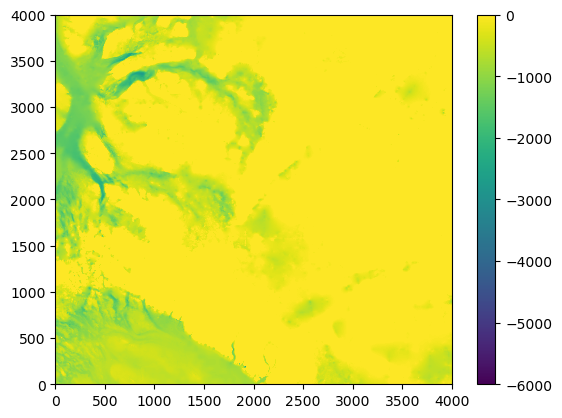

In [4]:
plt.pcolormesh(ds.z.isel(y=slice(8000,12000), x=slice(8000,12000)), vmin=-6000, vmax=0)
plt.colorbar()
plt.show()

In [6]:
import numpy as np
from pyproj import Transformer


# Instantiate the transofomer for Polar Sterographic (ESPG:9354) to regular lat/lon (EPSG:4326)
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:9354', always_xy=True)

# Get coordinate grids
X, Y = np.meshgrid(ds.x, ds.y)

# Generate lat/lon from the y/x coordinate grids via the transformer
lat, lon = transformer.transform(X, Y)

In [9]:
import sys

# Get to root for imports
sys.path.append("/home/jbassham/jack/thesis-rough")

In [10]:
from _02_regrid.core_regrid import (
    OldGridProj,
    GridSpecs,
)
from _02_regrid.pipeline_regrid import regrid_dataset

from _00_config.load_config import load_config
cfg = load_config()

ModuleNotFoundError: No module named '_02_regrid'

In [ ]:
scalar_field = {'z': ds.z.values}

# Instantiate old grid projection object
old_grid_proj = OldGridProj(
    lat_mesh = lat,
    lon_mesh = lon,
)

# Instantiate new grid specifications object
grid_specs = GridSpecs(
    lat_bounds = cfg.data_config.latitude_bounds,
    lon_bounds = cfg.data_config.longitude_bounds,
    resolution_km = cfg.data_config.grid_resolution,
)

# Regrid vector and scalar data and create new grid lat/lon
_, scalars_regrid, new_reg_grid = regrid_dataset(
    old_grid_proj, grid_specs, 
    cfg.data_config.hemisphere,
    scalar_fields = scalar_field, 
)